In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import normalize
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

In [2]:
ALPHA=0.1
BETA=0.1
DELTA_MAX=0.015

In [3]:
import pandas as pd
import glob
import os

# Directory path
csv_dir = "/scratch/project/tcr_ml/gnn_release/old_folders/icantcrscoring/model_2025_sc_curated/aml_zero"

# Get all CSV files in the directory
csv_files = [
    f for f in glob.glob(os.path.join(csv_dir, "*.csv"))
    if os.path.basename(f) != "summary.csv"
]
# Load all CSV files into a list of DataFrames
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    # Optional: add a column to track which file the data came from
    df['source_file'] = os.path.basename(file)
    dataframes.append(df)

# If you want to combine all DataFrames into one
combined_df = pd.concat(dataframes, ignore_index=True)

combined_df

,AA_seq,CloneFreq,prob,high,transformed_score,source_file
0,CASSDQGVNEQFF,0.055556,0.024469,False,0.001359,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
1,CASSPQTGDTDTQYF,0.037037,0.040908,False,0.001515,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
2,CSAPGSGVMRSTDTQYF,0.027778,0.000042,False,0.000001,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
3,CSASVW,0.027778,0.294831,False,0.008190,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
4,CATSDRQGNTEAFF,0.027778,0.996675,True,0.027686,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
...,...,...,...,...,...,...
13690,CASSRPALEQGNYGYTF,0.009091,0.984525,True,0.008950,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...
13691,CASRLIDSFSYEQYF,0.009091,0.963227,True,0.008757,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...
13692,CSARGGMSYEQYF,0.009091,0.695003,True,0.006318,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...
13693,CASSKGYLETQYF,0.009091,0.727591,True,0.006615,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...


In [4]:
df = pd.read_csv("/scratch/project/tcr_ml/gnn_release/research_scripts/bulk+sc_scores/aml_zero_sample_scores.csv")
df

,source,sequence,scores
0,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CSVDSTGELGYTF,0.914408
1,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CSVEGQEVDYGYTF,0.888662
2,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CASSLTPGNTGELFF,0.554450
3,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CASSLGDRGPYSNQPQHF,0.407604
4,01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...,CASSLGGGHGNRYTF,0.427550
...,...,...,...
13395,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSVSFAGHPRTDTQYF,0.093096
13396,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSASPPTGLNTEAFF,0.579597
13397,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSASPPTGLNTEAFF,0.579597
13398,P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...,CSAGQRMGEQFF,0.792625


In [5]:
# Build a unique mapping: AA_seq -> first score in df
score_map = df.groupby("sequence")["scores"].first()

# Filter combined_df to only sequences present in df
filtered = combined_df[combined_df["AA_seq"].isin(score_map.index)]

# Replace prob using the safe unique mapping
filtered["prob"] = filtered["AA_seq"].map(score_map)

combined_df = filtered.copy()
combined_df

,AA_seq,CloneFreq,prob,high,transformed_score,source_file
0,CASSDQGVNEQFF,0.055556,0.502307,False,0.001359,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
1,CASSPQTGDTDTQYF,0.037037,0.537616,False,0.001515,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
2,CSAPGSGVMRSTDTQYF,0.027778,0.251401,False,0.000001,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
3,CSASVW,0.027778,0.715898,False,0.008190,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
4,CATSDRQGNTEAFF,0.027778,0.353730,True,0.027686,P005808_386805_T_R_HFF3MDSX7_CACTCAATTC-CACAAC...
...,...,...,...,...,...,...
13690,CASSRPALEQGNYGYTF,0.009091,0.610891,True,0.008950,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...
13691,CASRLIDSFSYEQYF,0.009091,0.156377,True,0.008757,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...
13692,CSARGGMSYEQYF,0.009091,0.055403,True,0.006318,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...
13693,CASSKGYLETQYF,0.009091,0.181943,True,0.006615,04-0070_410882_T_R_22J2HKLT3_TTACGCACCT-GCTCTC...


In [6]:
import numpy as np

# ----------------------------- Utilities -------------------------------- #

def _apply_open_interval(arr, open_interval: bool, eps: float):
    if not open_interval:
        return arr
    out = arr.copy()
    out[out <= 0.0] = eps
    out[out >= 1.0] = 1.0 - eps
    return out

def _plotting_position(ranks, m, method: str):
    if method == "weibull":
        return ranks / (m + 1.0)
    if method == "hazen":
        return (ranks - 0.5) / m
    if method == "blom":
        return (ranks - 0.375) / (m + 0.25)
    if method == "bernard":
        return (ranks - 3.0/8.0) / (m + 0.25)
    if method == "rank":
        return np.full(m, 0.5) if m == 1 else (ranks - 1.0) / (m - 1.0)
    raise ValueError(f"Unknown method '{method}'")

def _midranks_for_ties(sorted_vals_len: int, diffs: np.ndarray):
    # diffs is np.diff of sorted values
    # build tie groups, assign midranks in 1..m
    m = sorted_vals_len
    if m == 0:
        return np.empty(0, dtype=float)
    boundaries = np.flatnonzero(diffs != 0.0)
    starts = np.r_[0, boundaries + 1]
    stops = np.r_[boundaries, m - 1]
    ranks = np.empty(m, dtype=float)
    for s, e in zip(starts, stops):
        mid = (s + e) / 2.0
        ranks[s:e+1] = mid + 1.0
    return ranks

# ----------------------------- Main API ---------------------------------- #

def fraction_to_percentile(
    x,
    weights=None,
    method="hazen",          # "weibull", "hazen", "blom", "bernard", "rank"
    open_interval=False,     # map [0,1] to (eps,1-eps) if True
    eps=1e-9,
    nan_policy="omit"        # "omit", "propagate", "raise"
):
    """
    Percentile transform via ECDF with optional weights and plotting positions.

    Unweighted case uses chosen plotting position with midranks for ties.
    Weighted case uses midpoint-of-jump ECDF which is method-free.

    Returns array of percentiles aligned with x.
    """
    x = np.asarray(x, dtype=float)
    n = x.size
    if n == 0:
        return x

    # NaN handling
    has_nan = np.isnan(x).any()
    if has_nan:
        if nan_policy == "raise":
            raise ValueError("NaNs present with nan_policy='raise'.")
        if nan_policy == "propagate":
            return np.full_like(x, np.nan, dtype=float)

    # Weights
    if weights is None:
        w = np.ones_like(x, dtype=float)
    else:
        w = np.asarray(weights, dtype=float)
        if w.shape != x.shape:
            raise ValueError("weights must have same shape as x")
        if np.any(w < 0):
            raise ValueError("weights must be nonnegative")

    # Filter valid
    valid = ~np.isnan(x)
    xv = x[valid]
    wv = w[valid]
    m = xv.size

    out = np.full_like(x, np.nan, dtype=float)
    if m == 0:
        return out
    if m == 1:
        out[valid] = 0.5
        return _apply_open_interval(out, open_interval, eps)

    # Sort by value
    order = np.argsort(xv, kind="mergesort")
    xv_sorted = xv[order]
    wv_sorted = wv[order]

    # Unweighted branch if all weights are 1
    if weights is None or np.allclose(wv_sorted, 1.0):
        diffs = np.diff(xv_sorted)
        ranks = _midranks_for_ties(len(xv_sorted), diffs)
        p_sorted = _plotting_position(ranks, m, method)
    else:
        # Weighted midpoint-of-jump ECDF at unique values
        uniq_vals, idx_start, counts = np.unique(
            xv_sorted, return_index=True, return_counts=True
        )
        group_weights = np.add.reduceat(wv_sorted, idx_start)
        cw = np.cumsum(group_weights)
        total = cw[-1]
        cw_prev = cw - group_weights
        p_group = (cw_prev + 0.5 * group_weights) / total
        p_sorted = np.repeat(p_group, counts)

    # Unsort back to valid positions
    inv = np.empty(m, dtype=int)
    inv[order] = np.arange(m)
    out[valid] = p_sorted[inv]
    return _apply_open_interval(out, open_interval, eps)

In [7]:
def sample_skewness(x):
    """
    Compute the Fisher-Pearson sample skewness of a 1D array.
    Returns 0.0 if fewer than 3 elements or zero variance.
    """
    import numpy as np

    x = np.asarray(x, dtype=float)
    if x.size < 3:
        return 0.0

    mu = x.mean()
    s = x.std(ddof=0)
    if s == 0:
        return 0.0

    return np.mean((x - mu) ** 3) / s**3

def combined_score_distribution_aware_simple(P, skew_strength=0.1, clip_strength=0.2, floor=0.0, ceil=1.0):
    """Shift scores based on distribution skew (right-skew → down, left-skew → up)."""
    import numpy as np
    from scipy.stats import skew

    P = np.clip(P, 0, 1)
    adj = -np.tanh(skew(P) * skew_strength) * clip_strength
    return np.clip(P + adj, floor, ceil)


def combined_score_sample_blend(P, F_raw, high_P=0.7, high_F=0.9, alpha=0.6, beta=0.8, gamma=0.5):
    """Blend scores P and frequencies F_raw using high-confidence weighting."""
    import numpy as np

    P = np.clip(P, 0, 1)
    R = fraction_to_percentile(F_raw)
    mask_high = (P > high_P) & (R > high_F)
    mask_low = (P < 1 - high_P) & (R < 1 - high_F)

    A_high = np.minimum(P, R) * mask_high
    A_low = np.minimum(1 - P, 1 - R) * mask_low

    S_adj = P + alpha * A_high - beta * A_low
    return np.clip((1 - gamma) * P + gamma * S_adj, 0, 1)



In [8]:
import numpy as np

combined_df['blend'] = combined_score_sample_blend(
    P=combined_df["prob"].values,
    F_raw=combined_df["CloneFreq"].values)
S = combined_score_distribution_aware_simple(
    P=combined_df["blend"].values)
# Add results back to the DataFrame
combined_df["score_adj"] = S
# combined_df["CloneFreq_percentile"] = R


In [9]:
import numpy as np
import pandas as pd


import numpy as np
import pandas as pd
from scipy.special import logit, expit, logsumexp
from scipy.stats import gmean

def summarize_probs(x, temperature=15):
    """Return all summary metrics for an array of probabilities, using scipy for stability."""
    x = np.asarray(x, dtype=float)
    x = np.clip(x, 1e-3, 1 - 1e-3)  # keep within (0,1)
    logits = logit(x)

    # Softmax pooling: smooth max of logits
    logsumexp_val = logsumexp(logits / temperature) - np.log(len(logits))
    softmax_pool = expit(logsumexp_val)

    return pd.Series({
        "arithmetic_mean": np.mean(x),
        "median": np.median(x),
        "geometric_mean": gmean(x),  # <- SciPy version
        "inv_logit_mean": expit(np.mean(logits)),
        "softmax_pool": softmax_pool,
        "arctan_compress": 0.5 + np.arctan(0.1 * np.mean(logits)) / np.pi
    })



summary_by_source = combined_df.groupby("source_file")["score_adj"].apply(summarize_probs).reset_index()


# compute arithmetic mean of untransformed 'prob'
old_means = (
    combined_df.groupby("source_file")["prob"]
    .mean()
    .rename("score_adj")  # same column name for consistency
    .reset_index()
)
old_means["level_1"] = "old_arithmetic_mean"

# append as new rows
summary_by_source = pd.concat([summary_by_source, old_means], ignore_index=True)

# optional: reorder columns
summary_by_source = summary_by_source[["source_file", "level_1", "score_adj"]]

# if you want it as a clean dataframe instead of hierarchical columns
summary_by_source = summary_by_source.reset_index()

print(summary_by_source)


     index                                        source_file  \
0        0  01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...   
1        1  01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...   
2        2  01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...   
3        3  01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...   
4        4  01-0051_409375_T_R_22HM3TLT3_TCAGAAGGCG-GGCCAT...   
..     ...                                                ...   
317    317  P014801_368933_T_R_HVJJLDSX3_TACGTGAAGG-CTAATA...   
318    318  P017204_383316_T_R_H3LVMDSX7_TGGAGTACTT-TCCACA...   
319    319  P018501_362876_T_R_HJWVCDSX3_GGTCTATTAA-CGTGTC...   
320    320  P021101_378759_T_R_HMHMYDSX5_TCTATCCTAA-CCAGTC...   
321    321  P021501_381133_T_R_HWWC5DSX5_CTCTGCAGCG-TACATC...   

                 level_1  score_adj  
0        arithmetic_mean   0.458964  
1                 median   0.453371  
2         geometric_mean   0.376322  
3         inv_logit_mean   0.461566  
4           softmax_pool   0.

In [10]:
count_below = (combined_df['score_adj'] < 0.01).sum()
prob_count = (combined_df['prob'] < 0.01).sum()

# Percentage increase from prob_count to count_below
if prob_count != 0:
    pct_increase = ((count_below - prob_count) / prob_count) * 100
else:
    pct_increase = float('inf')  # Avoid divide-by-zero error

print(f"Number of rows where score_adj < 0.01: {count_below}")
print(f"Number of rows where prob < 0.01: {prob_count}")
print(f"Percentage increase: {pct_increase:.2f}%")



Number of rows where score_adj < 0.01: 334
Number of rows where prob < 0.01: 23
Percentage increase: 1352.17%


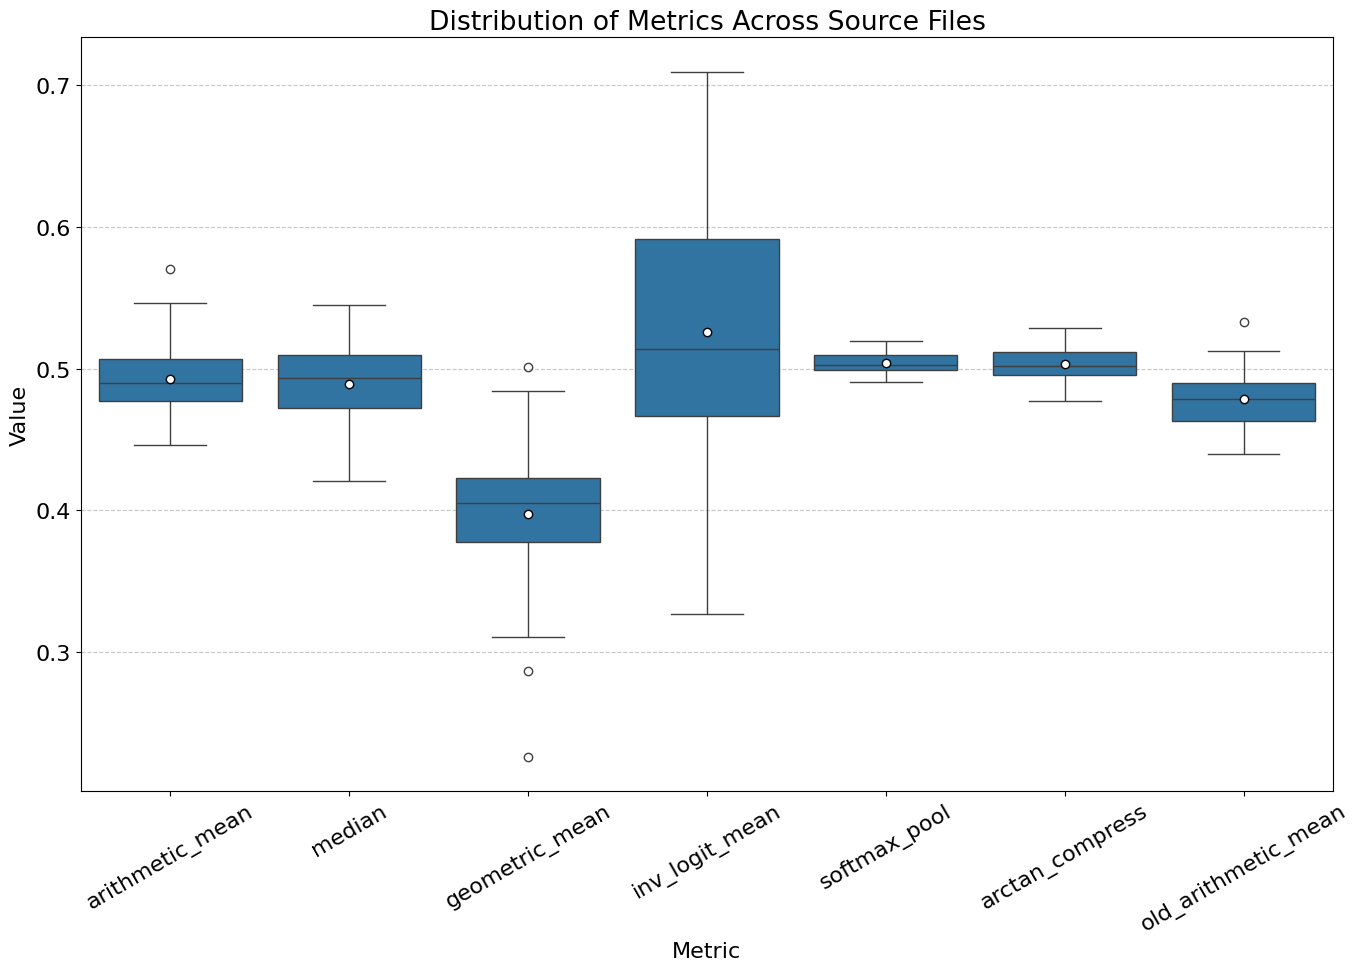

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure your DataFrame is named correctly, e.g.:
df_summary = summary_by_source  # or whatever variable you used

plt.figure(figsize=(14, 10))
sns.boxplot(data=df_summary, x="level_1", y="score_adj", showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"})

plt.title("Distribution of Metrics Across Source Files")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [12]:
# Directory path
csv_dir = "/scratch/project/tcr_ml/gnn_release/old_folders/icantcrscoring/model_2025_sc_curated/PICA"

# Get all CSV files in the directory
csv_files = [
    f for f in glob.glob(os.path.join(csv_dir, "*.csv"))
    if os.path.basename(f) != "summary.csv"
]
# Load all CSV files into a list of DataFrames
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    # Optional: add a column to track which file the data came from
    df['source_file'] = os.path.basename(file)
    dataframes.append(df)

# If you want to combine all DataFrames into one
combined_control_df = pd.concat(dataframes, ignore_index=True)

combined_control_df

,AA_seq,CloneFreq,prob,high,transformed_score,source_file
0,CASTPGDEQYF,0.003607,0.575344,False,0.002075,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
1,CASSLGSGQYF,0.001945,0.588268,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
2,CASSLGSGQYF,0.001945,0.588268,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
3,CASSLGSGQYF,0.001945,0.588268,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
4,CASSLGSGQYF,0.001945,0.588268,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
...,...,...,...,...,...,...
149200,CATSDSTRGDSYNEQFF,0.000038,0.144616,False,0.000005,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...
149201,CSAGGDRSNQPQHF,0.000038,0.086664,False,0.000003,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...
149202,CSAREPGSSPLHF,0.000038,0.909164,True,0.000035,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...
149203,CAISETSEVGYEQYF,0.000038,0.329552,False,0.000013,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...


In [13]:
control_df = pd.read_csv("/scratch/project/tcr_ml/gnn_release/research_scripts/bulk+sc_scores/pica_complete_sample_scores.csv")

# 1. Make AA_seq -> score mapping with unique index
score_map = control_df.groupby("sequence")["scores"].first()

# 2. Filter combined_control_df to only rows that exist in control_df
mask = combined_control_df["AA_seq"].isin(score_map.index)
filtered_control = combined_control_df.loc[mask].copy()

# 3. Replace prob using the map
filtered_control["prob"] = filtered_control["AA_seq"].map(score_map)

# check
len(control_df), len(combined_control_df), len(filtered_control)
combined_control_df = filtered_control.copy()
combined_control_df 

,AA_seq,CloneFreq,prob,high,transformed_score,source_file
0,CASTPGDEQYF,0.003607,0.790355,False,0.002075,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
1,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
2,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
3,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
4,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...
...,...,...,...,...,...,...
149200,CATSDSTRGDSYNEQFF,0.000038,0.573516,False,0.000005,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...
149201,CSAGGDRSNQPQHF,0.000038,0.254204,False,0.000003,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...
149202,CSAREPGSSPLHF,0.000038,0.704081,True,0.000035,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...
149203,CAISETSEVGYEQYF,0.000038,0.645334,False,0.000013,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...


In [14]:
import numpy as np

# # Apply the function to the DataFrame
# S, R = combined_score_sample_capped(
#     P=combined_control_df["prob"].values,
#     F_raw=combined_control_df["CloneFreq"].values,
#     t_P=0.5,
#     t_R=0.5,
#     alpha=ALPHA,
#     beta=BETA,
#     delta_max=DELTA_MAX,
#     floor=0.01,
#     ceil=0.99,
# )
combined_control_df['blend'] = combined_score_sample_blend(
    P=combined_control_df["prob"].values,
    F_raw=combined_control_df["CloneFreq"].values)
S = combined_score_distribution_aware_simple(
    P=combined_control_df["blend"].values)
# Add results back to the DataFrame
combined_control_df["score_adj"] = S
# combined_control_df["CloneFreq_percentile"] = R
combined_control_df

,AA_seq,CloneFreq,prob,high,transformed_score,source_file,blend,score_adj
0,CASTPGDEQYF,0.003607,0.790355,False,0.002075,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,1.000000,1.000000
1,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,0.477418,0.478308
2,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,0.477418,0.478308
3,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,0.477418,0.478308
4,CASSLGSGQYF,0.001945,0.477418,False,0.001144,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,0.477418,0.478308
...,...,...,...,...,...,...,...,...
149200,CATSDSTRGDSYNEQFF,0.000038,0.573516,False,0.000005,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,0.573516,0.574406
149201,CSAGGDRSNQPQHF,0.000038,0.254204,False,0.000003,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,0.254204,0.255094
149202,CSAREPGSSPLHF,0.000038,0.704081,True,0.000035,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,0.704081,0.704971
149203,CAISETSEVGYEQYF,0.000038,0.645334,False,0.000013,20241106_WGS_20241106_sc_PICA0033-PICA0069_Poo...,0.645334,0.646225


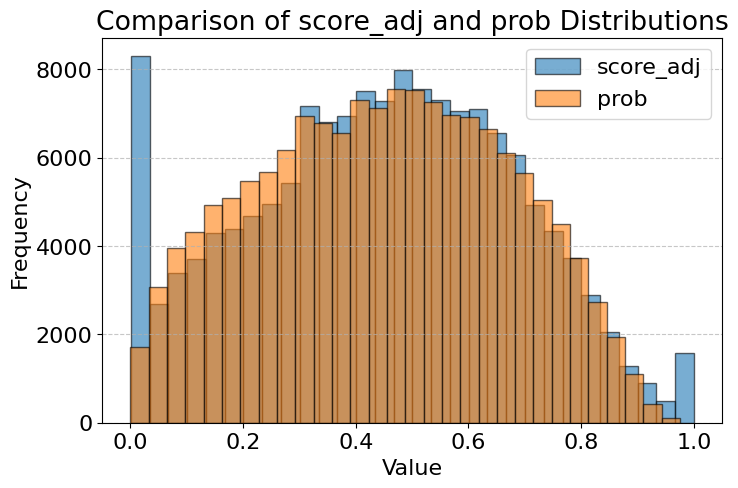

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot histograms for both columns
plt.hist(combined_control_df['score_adj'], bins=30, alpha=0.6, label='score_adj', edgecolor='black')
plt.hist(combined_control_df['prob'], bins=30, alpha=0.6, label='prob', edgecolor='black')

# Labels and title
plt.title('Comparison of score_adj and prob Distributions')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



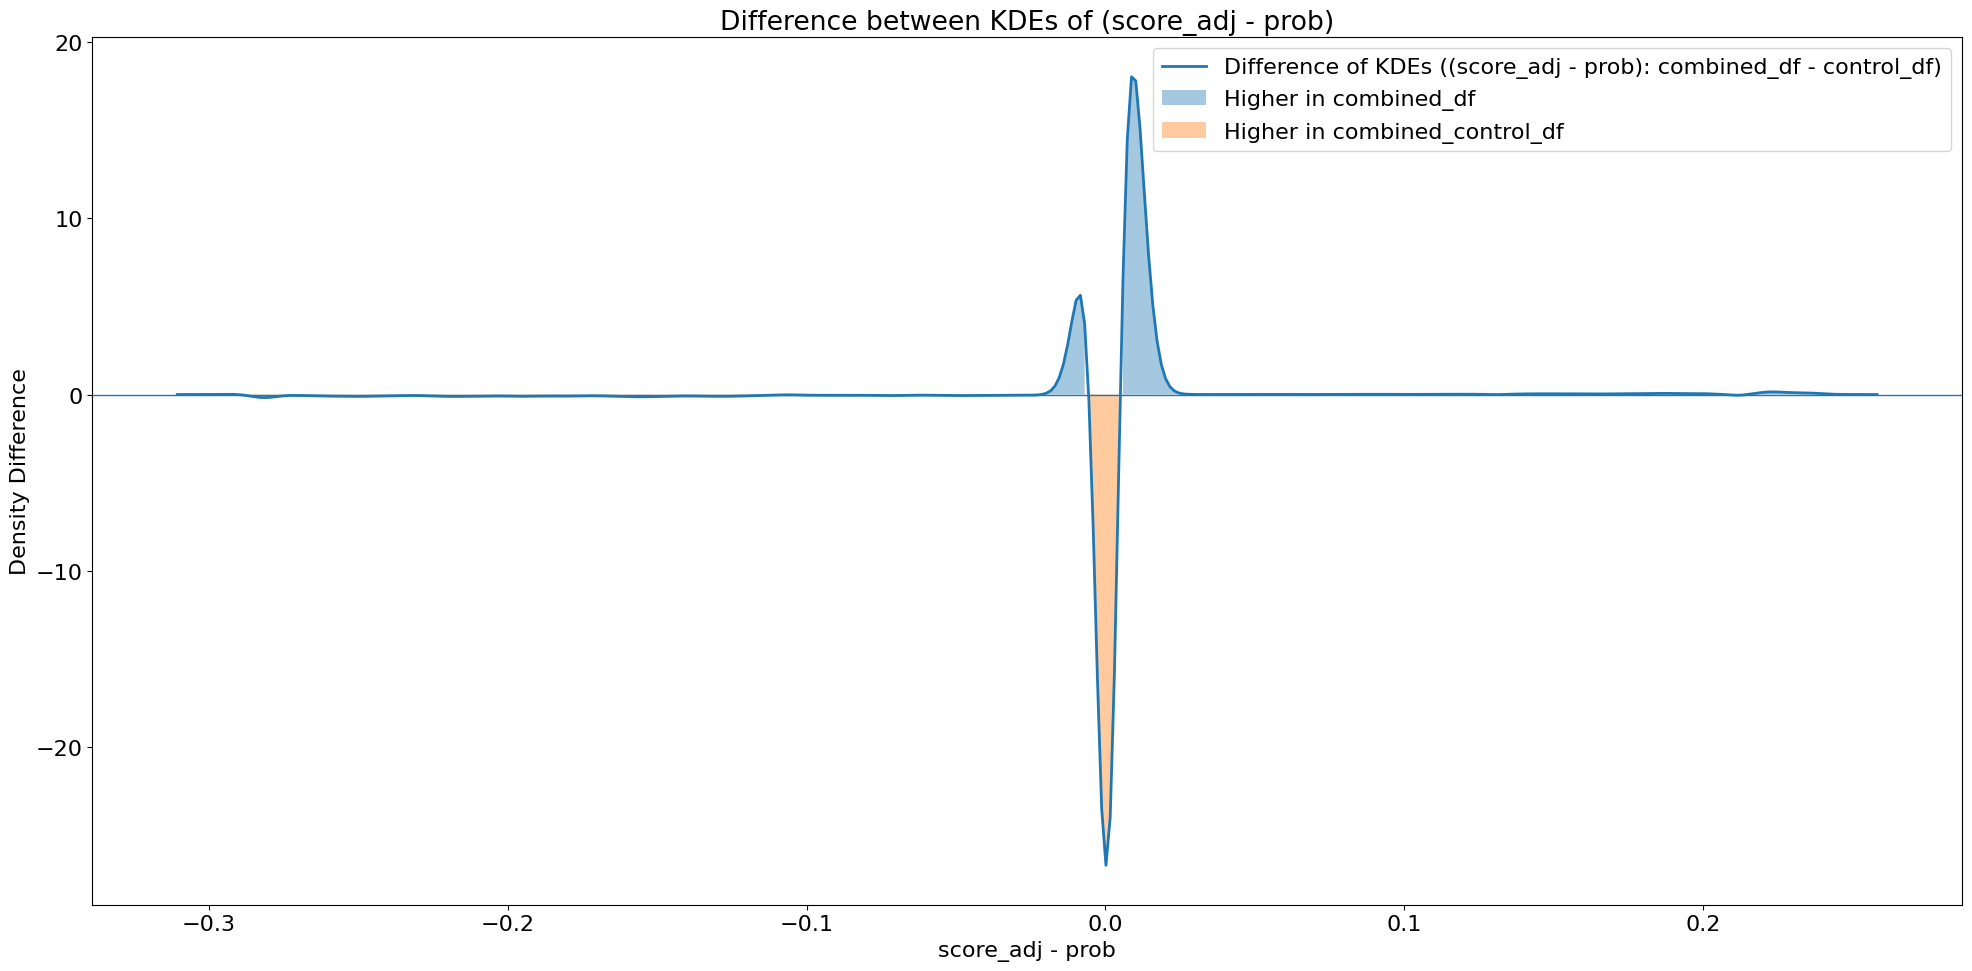

In [16]:
# Compute and plot the *difference* between the two KDE curves of (score_adj - prob)
# for combined_df and combined_control_df

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import gaussian_kde  # type: ignore
    _HAVE_SCIPY = True
except Exception:
    _HAVE_SCIPY = False

def _kde_gaussian_numpy(samples: np.ndarray, x_grid: np.ndarray, bandwidth: float | None = None) -> np.ndarray:
    samples = samples[~np.isnan(samples)]
    n = samples.size
    if n == 0:
        return np.zeros_like(x_grid)
    std = samples.std(ddof=1) if n > 1 else 1e-6
    if bandwidth is None or bandwidth <= 0:
        bandwidth = 1.06 * std * n ** (-1/5)
        if bandwidth <= 1e-12:
            bandwidth = 1e-3
    diffs = (x_grid[:, None] - samples[None, :]) / bandwidth
    kernel_vals = np.exp(-0.5 * diffs**2) / np.sqrt(2 * np.pi)
    density = kernel_vals.sum(axis=1) / (n * bandwidth)
    return density

def kde_1d(samples: np.ndarray, x_grid: np.ndarray, bw_adjust: float = 1.0) -> np.ndarray:
    samples = samples[~np.isnan(samples)]
    if samples.size == 0:
        return np.zeros_like(x_grid)
    if _HAVE_SCIPY:
        kde = gaussian_kde(samples)
        default_factor = kde.covariance_factor()
        kde.set_bandwidth(bw_method=default_factor / bw_adjust)
        return kde.evaluate(x_grid)
    else:
        return _kde_gaussian_numpy(samples, x_grid)

def plot_difference_between_diffs(df1: pd.DataFrame, df2: pd.DataFrame,
                                  prob_col: str = "prob", adj_col: str = "score_adj",
                                  bw_adjust: float = 1.0,
                                  n_points: int = 400):
    d1 = (df1[adj_col] - df1[prob_col]).to_numpy(dtype=float)
    d2 = (df2[adj_col] - df2[prob_col]).to_numpy(dtype=float)

    lo = np.nanmin([np.nanmin(d1), np.nanmin(d2)])
    hi = np.nanmax([np.nanmax(d1), np.nanmax(d2)])
    pad = 0.05 * (hi - lo if np.isfinite(hi - lo) and (hi - lo) > 0 else 1.0)
    x_common = np.linspace(lo - pad, hi + pad, n_points)

    y1 = kde_1d(d1, x_common, bw_adjust=bw_adjust)
    y2 = kde_1d(d2, x_common, bw_adjust=bw_adjust)
    y_diff = y1 - y2

    plt.figure(figsize=(20, 10))
    plt.plot(x_common, y_diff, linewidth=2, label="Difference of KDEs ((score_adj - prob): combined_df - control_df)")
    plt.fill_between(x_common, 0, y_diff, where=(y_diff > 0), alpha=0.4, label="Higher in combined_df")
    plt.fill_between(x_common, 0, y_diff, where=(y_diff < 0), alpha=0.4, label="Higher in combined_control_df")
    plt.axhline(0, linewidth=1)
    plt.title("Difference between KDEs of (score_adj - prob)")
    plt.xlabel("score_adj - prob")
    plt.ylabel("Density Difference")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Use user data if available, else demo
_use_demo = False
if "combined_df" in globals() and "combined_control_df" in globals():
    _df1 = globals()["combined_df"]
    _df2 = globals()["combined_control_df"]
    if all(isinstance(df, pd.DataFrame) and {"prob", "score_adj"}.issubset(df.columns) for df in [_df1, _df2]):
        plot_difference_between_diffs(_df1, _df2, prob_col="prob", adj_col="score_adj", bw_adjust=1.0)
    else:
        _use_demo = True


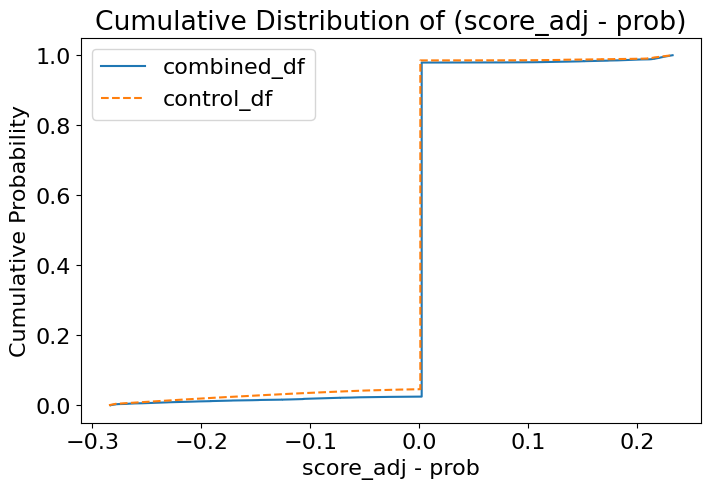

In [17]:
import matplotlib.pyplot as plt
import numpy as np

diff_combined = (combined_df['score_adj'] - combined_df['prob']).sort_values().to_numpy()
diff_control = (combined_control_df['score_adj'] - combined_control_df['prob']).sort_values().to_numpy()

plt.figure(figsize=(8, 5))
plt.plot(diff_combined, np.linspace(0, 1, len(diff_combined)), label='combined_df')
plt.plot(diff_control, np.linspace(0, 1, len(diff_control)), label='control_df', linestyle='--')
plt.title('Cumulative Distribution of (score_adj - prob)')
plt.xlabel('score_adj - prob')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.show()


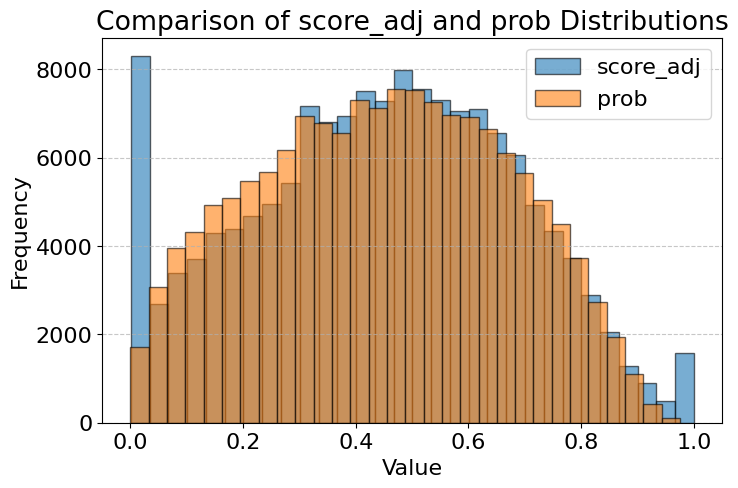

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Plot histograms for both columns
plt.hist(combined_control_df['score_adj'], bins=30, alpha=0.6, label='score_adj', edgecolor='black')
plt.hist(combined_control_df['prob'], bins=30, alpha=0.6, label='prob', edgecolor='black')

# Labels and title
plt.title('Comparison of score_adj and prob Distributions')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()



In [19]:
import numpy as np
import pandas as pd


# summarize for score_adj
summary_by_source = combined_control_df.groupby("source_file")["score_adj"].apply(summarize_probs).reset_index()

# compute arithmetic mean of untransformed 'prob'
old_means = (
    combined_control_df.groupby("source_file")["prob"]
    .mean()
    .rename("score_adj")  # same column name for consistency
    .reset_index()
)
old_means["level_1"] = "old_arithmetic_mean"

# append as new rows
summary_by_source = pd.concat([summary_by_source, old_means], ignore_index=True)

# optional: reorder columns
summary_by_source = summary_by_source[["source_file", "level_1", "score_adj"]]

summary_by_source


,source_file,level_1,score_adj
0,20240530_WGS_20240530_sc_PICA0001-PICA0007_PMI...,arithmetic_mean,0.448044
1,20240530_WGS_20240530_sc_PICA0001-PICA0007_PMI...,median,0.448118
2,20240530_WGS_20240530_sc_PICA0001-PICA0007_PMI...,geometric_mean,0.368640
3,20240530_WGS_20240530_sc_PICA0001-PICA0007_PMI...,inv_logit_mean,0.430373
4,20240530_WGS_20240530_sc_PICA0001-PICA0007_PMI...,softmax_pool,0.496194
...,...,...,...
163,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,old_arithmetic_mean,0.442254
164,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,old_arithmetic_mean,0.449296
165,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,old_arithmetic_mean,0.437410
166,20250114_WGS_20241218_sc_PICA0071-PICA0097_Poo...,old_arithmetic_mean,0.454393


In [20]:
count_below = (combined_control_df['score_adj'] < 0.01).sum()
prob_count = (combined_control_df['prob'] < 0.01).sum()

# Percentage increase from prob_count to count_below
if prob_count != 0:
    pct_increase = ((count_below - prob_count) / prob_count) * 100
else:
    pct_increase = float('inf')  # Avoid divide-by-zero error

print(f"Number of rows where score_adj < 0.01: {count_below}")
print(f"Number of rows where prob < 0.01: {prob_count}")
print(f"Percentage increase: {pct_increase:.2f}%")



Number of rows where score_adj < 0.01: 6748
Number of rows where prob < 0.01: 254
Percentage increase: 2556.69%


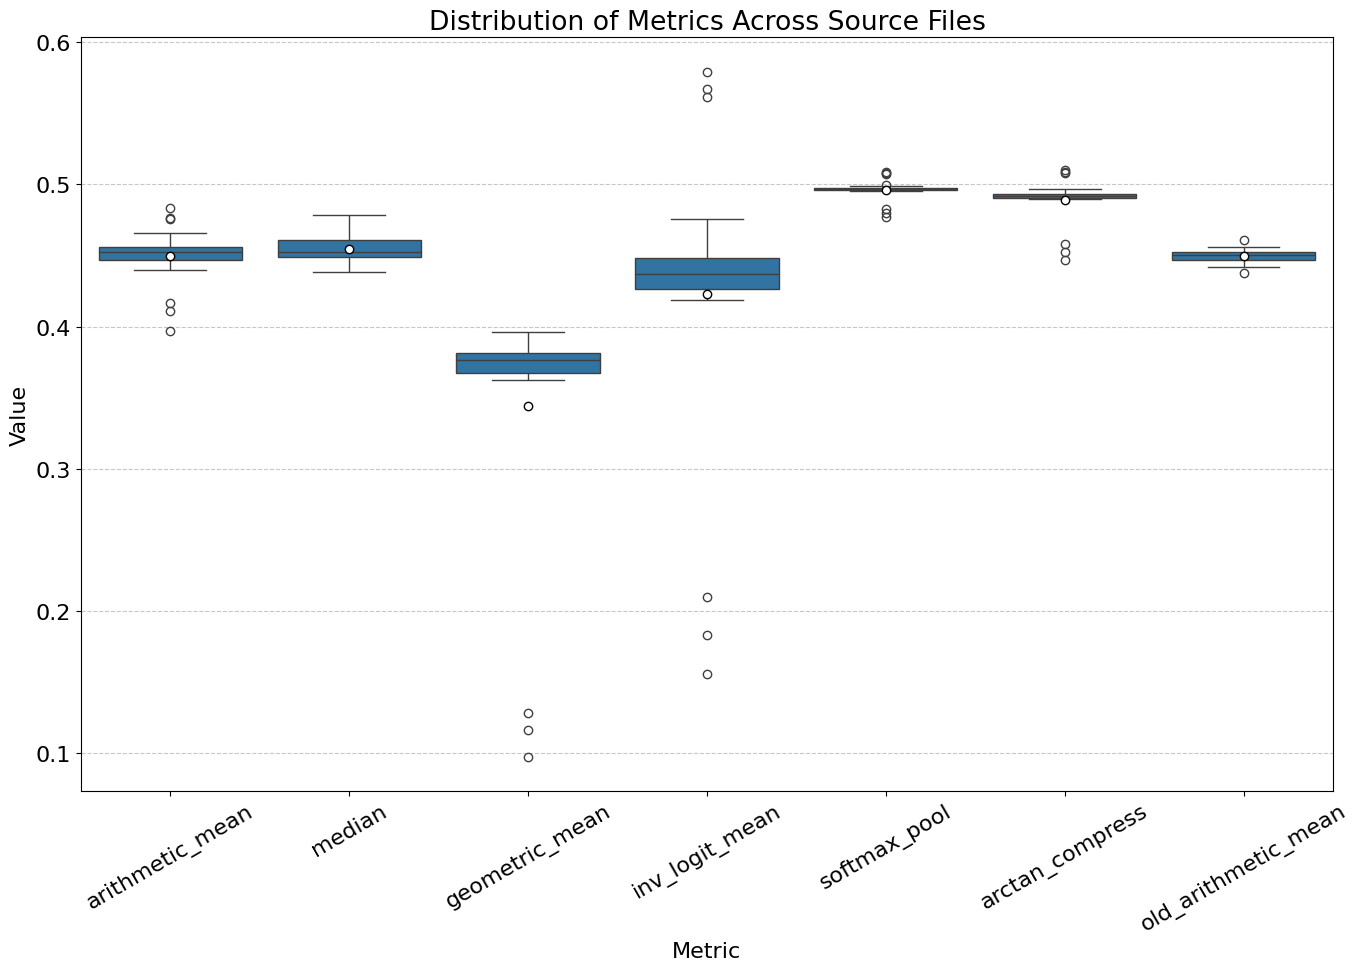

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make sure your DataFrame is named correctly, e.g.:
df_summary_control = summary_by_source  # or whatever variable you used

plt.figure(figsize=(14, 10))
sns.boxplot(data=df_summary_control, x="level_1", y="score_adj", showmeans=True,
            meanprops={"marker": "o", "markerfacecolor": "white", "markeredgecolor": "black"})

plt.title("Distribution of Metrics Across Source Files")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


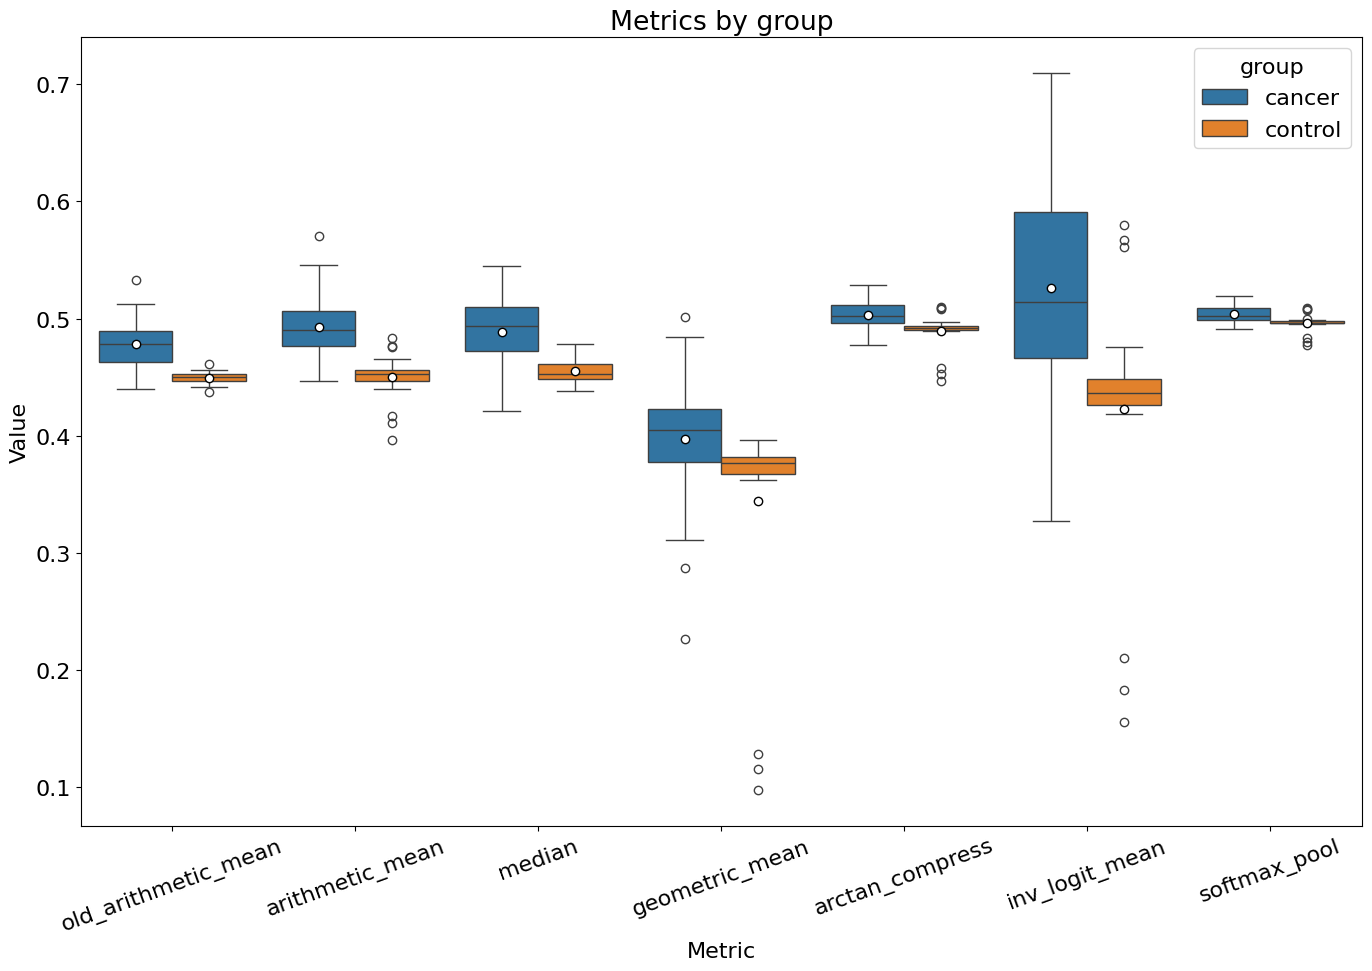

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tag and combine
dfc = df_summary.copy()
dfc["group"] = "cancer"
dfk = df_summary_control.copy()
dfk["group"] = "control"
df_long = pd.concat([dfc, dfk], ignore_index=True)

# Pick metric order if you want consistent x positions
metrics = ["old_arithmetic_mean","arithmetic_mean", "median", "geometric_mean", "arctan_compress", "inv_logit_mean","softmax_pool"]
metrics = [m for m in metrics if m in df_long["level_1"].unique()]

plt.figure(figsize=(14, 10))
sns.boxplot(
    data=df_long,
    x="level_1",
    y="score_adj",
    hue="group",
    order=metrics,
    showmeans=True,
    meanprops={"marker":"o","markerfacecolor":"white","markeredgecolor":"black"}
)
plt.title("Metrics by group")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


/scratch/temp/18578253/ipykernel_3758578/44752821.py:35: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(tpr, fpr)


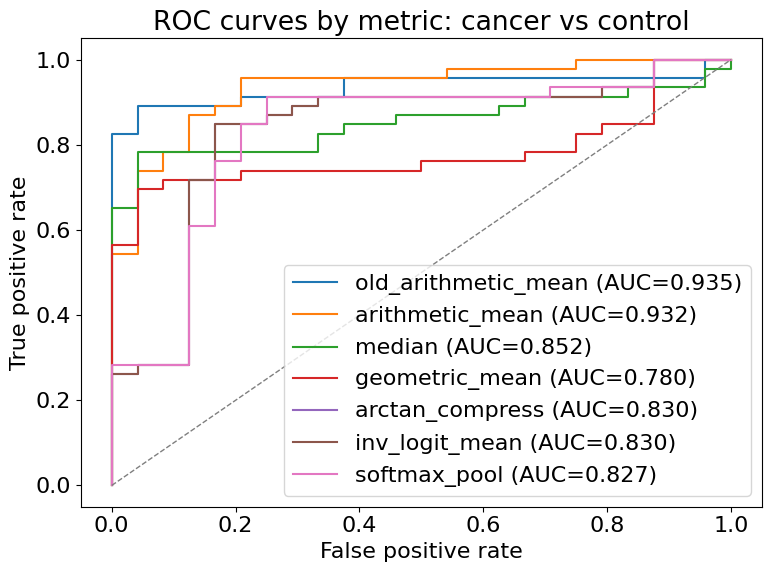

             metric      auc
old_arithmetic_mean 0.934783
    arithmetic_mean 0.932065
             median 0.852355
    arctan_compress 0.829710
     inv_logit_mean 0.829710
       softmax_pool 0.826993
     geometric_mean 0.779891


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Expecting:
# df_summary, df_summary_control with columns: ["source_file", "level_1", "score_adj"]

def roc_curve_manual(y_true: np.ndarray, y_score: np.ndarray):
    y_true = y_true.astype(int)
    order = np.argsort(-y_score)              # sort by score desc
    y_true_sorted = y_true[order]
    y_score_sorted = y_score[order]

    P = y_true_sorted.sum()
    N = len(y_true_sorted) - P
    if P == 0 or N == 0:
        # cannot compute ROC if only one class present
        return np.array([0.0, 1.0]), np.array([0.0, 1.0]), np.nan

    tps = np.cumsum(y_true_sorted)
    fps = np.cumsum(1 - y_true_sorted)

    # take points only where score changes, plus last point
    diffs = np.diff(y_score_sorted)
    idx = np.where(diffs != 0)[0]
    idx = np.r_[idx, len(y_true_sorted) - 1]

    tpr = tps[idx] / P
    fpr = fps[idx] / N

    # add origin
    tpr = np.r_[0.0, tpr]
    fpr = np.r_[0.0, fpr]

    auc = np.trapz(tpr, fpr)
    return fpr, tpr, auc

# Tag group and combine
dfc = df_summary.copy();            dfc["group"] = "cancer"
dfk = df_summary_control.copy();    dfk["group"] = "control"
df_long = pd.concat([dfc, dfk], ignore_index=True)

# Coerce numeric
df_long["score_adj"] = pd.to_numeric(df_long["score_adj"], errors="coerce")

# Which metrics to compare
metrics = ["old_arithmetic_mean","arithmetic_mean", "median", "geometric_mean", "arctan_compress", "inv_logit_mean","softmax_pool"]
metrics = [m for m in metrics if m in df_long["level_1"].unique()]

# Plot ROC curves
plt.figure(figsize=(8, 6))
auc_rows = []

for m in metrics:
    sub = df_long[df_long["level_1"] == m].dropna(subset=["score_adj", "group"])
    if sub.empty:
        continue
    y_true = (sub["group"].values == "cancer").astype(int)
    y_score = sub["score_adj"].values.astype(float)

    fpr, tpr, auc = roc_curve_manual(y_true, y_score)
    auc_rows.append({"metric": m, "auc": auc})

    plt.plot(fpr, tpr, label=f"{m} (AUC={auc:.3f})")

# diagonal
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves by metric: cancer vs control")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# AUC table
auc_df = pd.DataFrame(auc_rows).sort_values("auc", ascending=False)
print(auc_df.to_string(index=False))
